# Matching Notebook for Hospital Merger DiD

This notebook builds a matched hospital sample before rerunning Difference-in-Differences (DiD).

Motivation: prior parallel-trends checks suggested treated and never-treated hospitals had different pre-treatment dynamics.

### Overview

This section validates the parallel-trends assumption using the matched hospital panel created earlier in this notebook.

After matching treated and never-treated hospitals on pre-treatment characteristics, we run a pre-period diagnostic to assess whether treated and control units evolve similarly before merger exposure.

### Staggered DiD Design Context

This project uses a staggered Difference-in-Differences design, where hospitals enter treatment (merger exposure) in different years.

Because treatment timing differs across hospitals, the parallel-trends check is performed in event time relative to each hospital's merger year and then mapped to comparable calendar years for controls.

For this diagnostic, we restrict treated hospitals to merger cohorts 2013 to 2017 and keep event time in [-2, +2], with a formal pre-period check based on years_to_merger in [-2, -1].

### Objectives

- Build a clean pre-period sample with consistent treatment-timing fields
- Restrict treated observations to cohorts 2013 to 2017 and event time [-2, +2]
- Align never-treated controls to the same calendar years as treated pre-period observations
- Visualize pre-trends in mean log cost per discharge
- Run a joint interaction test for treated-by-year pre-period differences
- Conclude whether there is evidence against parallel trends after matching

### Dataset Description

Input data for this section comes from `01_data/hospital_analysis_matched.csv`, which is the matched panel saved in Step 7.

Core variables used here are fiscal_year, treated, merger_year, years_to_merger, and cost_per_discharge.

The outcome is transformed as log(1 + cost_per_discharge) to reduce skew and improve interpretability of trend differences.

### Key Considerations

- Parallel trends concerns similarity in slopes, not equality of baseline levels
- Visual diagnostics and formal tests should be interpreted together
- Pre-period sample size affects precision of the interaction-based hypothesis test

### Outcome

By the end of this section, we produce a pre-period trend plot and a formal joint F-test result for treated-by-year interactions, followed by a clear conclusion about whether the matched sample supports the parallel-trends assumption.

## Plan

1. Load and clean panel data.
2. Define treated and never-treated groups.
3. Build hospital-level pre-treatment features.
4. Prepare matching dataset.
5. Run 1:1 nearest-neighbor matching (without replacement) and a sensitivity check (with replacement).
6. Assess balance before vs after matching.
7. Rebuild and save matched panel.
8. Summarize and state the next step.

In [19]:
# Imports and display settings
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid", context="talk")

print("Libraries loaded.")

Libraries loaded.


## Step 1 - Load and Clean Data

We load `01_data/hospital_analysis.csv`, standardize key numeric columns, and drop invalid rows for core matching variables.

In [20]:
DATA_PATH = "../01_data/hospital_analysis.csv"

df = pd.read_csv(DATA_PATH)
print(f"Raw shape: {df.shape}")
print("Columns:", list(df.columns))
numeric_cols = [
    "fiscal_year",
    "treated",
    "merger_year",
    "years_to_merger",
    "cost_per_discharge",
    "total_operating_costs",
    "total_discharges",
]

# Convert only numeric columns that exist in the file
numeric_present = df.columns.intersection(numeric_cols)
df[numeric_present] = df[numeric_present].apply(pd.to_numeric, errors="coerce")
required_cols = [
    "PRVDR_NUM",
    "fiscal_year",
    "treated",
    "cost_per_discharge",
    "total_operating_costs",
    "total_discharges",
]
missing_required = sorted(set(required_cols) - set(df.columns))
assert not missing_required, f"Missing required columns: {missing_required}"

# Provider identifier used as hospital ID
df["PRVDR_NUM"] = df["PRVDR_NUM"].astype(str).str.strip()
before_drop = len(df)
df = df.dropna(subset=required_cols)

# Keep non-negative values for key outcome/covariates
for c in ["cost_per_discharge", "total_operating_costs", "total_discharges"]:
    df = df[df[c] >= 0]
# Keep only clear treatment coding
df = df[df["treated"].isin([0, 1])]
print(f"Rows dropped during cleaning: {before_drop - len(df):,}")
print(f"Cleaned shape: {df.shape}")
print("Unique hospitals:", df["PRVDR_NUM"].nunique())
print(
    "Fiscal year range:",
    int(df["fiscal_year"].min()),
    "to",
    int(df["fiscal_year"].max()),
)
df.head()

Raw shape: (55805, 30)
Columns: ['fiscal_year', 'RPT_REC_NUM', 'PRVDR_NUM', 'NPI', 'FY_BGN_DT', 'FY_END_DT', 'PRVDR_CTRL_TYPE_CD', 'total_operating_costs', 'net_patient_revenue', 'total_charges', 'medicare_charges', 'medicare_payments', 'medicaid_charges', 'medicaid_payments', 'total_discharges', 'cost_per_discharge', 'ccn', 'fac_name', 'hrrcode', 'merger_target', 'merger_of_equals', 'bankruptcy', 'system_exit', 'system_split', 'system_id_yr', 'any_merger', 'merger_year', 'treated', 'years_to_merger', 'post_merger']
Rows dropped during cleaning: 2,451
Cleaned shape: (53354, 30)
Unique hospitals: 6461
Fiscal year range: 2011 to 2019


,fiscal_year,RPT_REC_NUM,PRVDR_NUM,NPI,FY_BGN_DT,FY_END_DT,PRVDR_CTRL_TYPE_CD,total_operating_costs,net_patient_revenue,total_charges,medicare_charges,medicare_payments,medicaid_charges,medicaid_payments,total_discharges,cost_per_discharge,ccn,fac_name,hrrcode,merger_target,merger_of_equals,bankruptcy,system_exit,system_split,system_id_yr,any_merger,merger_year,treated,years_to_merger,post_merger
0,2011,1022,271326,NaN,01/01/2011,12/31/2011,2,8661723.0,10224482.0,9125.0,9840.0,NaN,922.0,10.0,155.0,55882.083871,271326,BEARTOOTH BILLINGS CLINIC,274.0,0,0,0,0,0,2246.0,0,NaN,0,NaN,0
1,2011,1501,13025,NaN,01/01/2011,12/31/2011,4,39554420.0,28191835.0,36500.0,NaN,NaN,23060.0,230.0,2390.0,16549.966527,13025,NaN,NaN,0,0,0,0,0,NaN,0,NaN,0,NaN,0
2,2011,1504,103037,NaN,01/01/2011,12/31/2011,4,20242022.0,15733902.0,25550.0,NaN,NaN,13304.0,699.0,1370.0,14775.198540,103037,NaN,NaN,0,0,0,0,0,NaN,0,NaN,0,NaN,0
3,2011,1506,103042,NaN,01/01/2011,12/31/2011,4,26136744.0,21786350.0,29200.0,NaN,NaN,18132.0,214.0,1495.0,17482.771906,103042,NaN,NaN,0,0,0,0,0,NaN,0,NaN,0,NaN,0
4,2011,1507,141990,NaN,01/01/2011,12/31/2011,1,116445.0,486669.0,6205.0,NaN,NaN,31.0,NaN,11.0,10585.909091,141990,NaN,NaN,0,0,0,0,0,NaN,0,NaN,0,NaN,0


## Step 2 - Define Treated and Control Units

Treated hospitals have `treated == 1`. Never-treated controls have `treated == 0` for all years.

For treated hospitals, we use the first merger year (`merger_year`) as the treatment cohort year.

In [21]:
# Hospital-level treatment classification

hospital_treat_flag = (
    df.groupby("PRVDR_NUM", as_index=False)["treated"]
    .max()
    .rename(columns={"treated": "ever_treated"})
)
treated_hospitals = set(
    hospital_treat_flag.loc[hospital_treat_flag["ever_treated"] == 1, "PRVDR_NUM"]
)
control_hospitals = set(
    hospital_treat_flag.loc[hospital_treat_flag["ever_treated"] == 0, "PRVDR_NUM"]
)
# First merger year for treated hospitals
treated_merger_year = (
    df[df["PRVDR_NUM"].isin(treated_hospitals) & df["merger_year"].notna()]
    .groupby("PRVDR_NUM", as_index=False)["merger_year"]
    .min()
    .rename(columns={"merger_year": "first_merger_year"})
)
treated_merger_year["first_merger_year"] = treated_merger_year[
    "first_merger_year"
].astype(int)
print("Treated hospitals (ever treated):", len(treated_hospitals))
print("Never-treated control hospitals:", len(control_hospitals))
print(
    "Treated hospitals with observed merger year:",
    treated_merger_year["PRVDR_NUM"].nunique(),
)
print(
    "Merger cohort years:",
    sorted(treated_merger_year["first_merger_year"].unique().tolist()),
)
treated_merger_year.head()

Treated hospitals (ever treated): 1242
Never-treated control hospitals: 5219
Treated hospitals with observed merger year: 1242
Merger cohort years: [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]


,PRVDR_NUM,first_merger_year
0,100002,2017
1,100014,2016
2,100023,2014
3,100026,2012
4,100030,2012


## Step 3 - Build Pre-Treatment Features

We create one row per hospital (for treated) and one row per hospital-cohort combination (for controls).

Pre-period logic:
- Use a fixed 2-year lookback window: cohort-5 to cohort-1.
- Require pre-treatment fiscal years to estimate slope.
- Drop treated hospitals failing this requirement and report the count.

In [22]:
PRE_YEARS = 2
id_col = "PRVDR_NUM"
ownership_col = "PRVDR_CTRL_TYPE_CD" if "PRVDR_CTRL_TYPE_CD" in df.columns else None
hrr_col = "hrrcode" if "hrrcode" in df.columns else None
treated_cohorts = sorted(
    treated_merger_year["first_merger_year"].dropna().astype(int).unique()
)


def safe_mode(s):
    s = s.dropna()
    return s.mode().iloc[0] if not s.empty else np.nan


def build_pre_features(g, cohort):
    start, end = int(cohort) - PRE_YEARS, int(cohort) - 1
    pre = g[(g["fiscal_year"] >= start) & (g["fiscal_year"] <= end)].copy()
    n_pre_years = pre["fiscal_year"].nunique()
    if n_pre_years < 2:
        return None
    year_avg = pre.groupby("fiscal_year", as_index=False)["cost_per_discharge"].mean()
    trend = (
        np.nan
        if year_avg["fiscal_year"].nunique() < 2
        else float(
            np.polyfit(year_avg["fiscal_year"], year_avg["cost_per_discharge"], 1)[0]
        )
    )
    return {
        "pre_mean_cost_per_discharge": pre["cost_per_discharge"].mean(),
        "pre_trend_cost_per_discharge": trend,
        "pre_mean_total_operating_costs": pre["total_operating_costs"].mean(),
        "pre_mean_total_discharges": pre["total_discharges"].mean(),
        "n_pre_years": n_pre_years,
        "ownership_type": safe_mode(pre[ownership_col]) if ownership_col else np.nan,
        "hrrcode": safe_mode(pre[hrr_col]) if hrr_col else np.nan,
    }


print("Using treated cohorts:", treated_cohorts)

Using treated cohorts: [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]


In [23]:
treated_rows = []
dropped_treated_insufficient_pre = 0
treated_map = dict(
    zip(treated_merger_year["PRVDR_NUM"], treated_merger_year["first_merger_year"])
)

for hosp_id, cohort in treated_map.items():
    g = df[df[id_col] == hosp_id]
    feats = build_pre_features(g, cohort)
    if feats is None:
        dropped_treated_insufficient_pre += 1
        continue
    feats.update({id_col: hosp_id, "merger_cohort": int(cohort), "treated_hospital": 1})
    treated_rows.append(feats)

control_rows = []
for hosp_id, g in df[df[id_col].isin(control_hospitals)].groupby(id_col):
    for cohort in treated_cohorts:
        feats = build_pre_features(g, cohort)
        if feats is None:
            continue
        feats.update(
            {id_col: hosp_id, "merger_cohort": int(cohort), "treated_hospital": 0}
        )
        control_rows.append(feats)

treated_features = pd.DataFrame(treated_rows)
control_features = pd.DataFrame(control_rows)

print("Treated hospitals dropped for <2 pre-years:", dropped_treated_insufficient_pre)
print("Treated feature rows:", treated_features.shape)
print("Control feature rows:", control_features.shape)
print("Unique treated hospitals retained:", treated_features[id_col].nunique())
print("Unique controls available:", control_features[id_col].nunique())

display(treated_features.head())
display(control_features.head())

Treated hospitals dropped for <2 pre-years: 249
Treated feature rows: (993, 10)
Control feature rows: (31752, 10)
Unique treated hospitals retained: 993
Unique controls available: 4980


,pre_mean_cost_per_discharge,pre_trend_cost_per_discharge,pre_mean_total_operating_costs,pre_mean_total_discharges,n_pre_years,ownership_type,hrrcode,PRVDR_NUM,merger_cohort,treated_hospital
0,15570.568715,-4326.419319,292739285.0,19218.5,2,2,118.0,100002,2017,1
1,20804.903155,-1106.509013,83996933.5,4043.0,2,9,131.0,100014,2016,1
2,15805.508771,200.508056,172101340.0,10888.5,2,2,129.0,100023,2014,1
3,15204.279098,607.027657,245271003.0,16147.0,2,2,139.0,100032,2013,1
4,12339.602090,-65.817416,59859706.5,4850.5,2,2,116.0,100043,2014,1


,pre_mean_cost_per_discharge,pre_trend_cost_per_discharge,pre_mean_total_operating_costs,pre_mean_total_discharges,n_pre_years,ownership_type,hrrcode,PRVDR_NUM,merger_cohort,treated_hospital
0,15994.897913,1902.219857,429012636.0,26913.0,2,2,123.0,100001,2013,0
1,15054.011107,-3783.993468,385374467.5,25631.0,2,2,123.0,100001,2014,0
2,16277.650000,6231.271255,410651223.5,25333.0,2,2,123.0,100001,2015,0
3,19227.564318,-331.442619,516794566.5,26896.0,2,2,123.0,100001,2016,0
4,19739.808041,1355.930064,572265249.5,28991.0,2,2,123.0,100001,2017,0


## Step 4 - Prepare Matching Dataset

We combine treated and control feature rows and keep only the pre-treatment continuous covariates used for matching.

These covariates are standardized before Mahalanobis distance matching.

In [24]:
match_df = pd.concat([treated_features, control_features], ignore_index=True)
print("Combined matching rows:", match_df.shape)
continuous_covariates = [
    "pre_mean_cost_per_discharge",
    "pre_trend_cost_per_discharge",
    "pre_mean_total_operating_costs",
    "pre_mean_total_discharges",
    "n_pre_years",
]
cohort_col = "merger_cohort"
base_cols = [id_col, "treated_hospital", cohort_col] + continuous_covariates
match_df = match_df[base_cols].copy()
print("Matching base shape:", match_df.shape)

Combined matching rows: (32745, 10)
Matching base shape: (32745, 8)


In [25]:
# Keep rows with complete matching covariates and cohort labels

before_na_drop = len(match_df)
match_df = match_df.dropna(subset=continuous_covariates + [cohort_col])
print("Rows dropped for missing matching inputs:", before_na_drop - len(match_df))

# Standardize continuous covariates before distance-based matching
scaler = StandardScaler()
match_design_scaled = match_df.copy()
match_design_scaled[continuous_covariates] = scaler.fit_transform(
    match_design_scaled[continuous_covariates]
)
feature_cols = continuous_covariates.copy()
print("Prepared matching design shape:", match_design_scaled.shape)
print("Continuous features used for Mahalanobis matching:", feature_cols)
match_design_scaled.head()

Rows dropped for missing matching inputs: 0
Prepared matching design shape: (32745, 8)
Continuous features used for Mahalanobis matching: ['pre_mean_cost_per_discharge', 'pre_trend_cost_per_discharge', 'pre_mean_total_operating_costs', 'pre_mean_total_discharges', 'n_pre_years']


,PRVDR_NUM,treated_hospital,merger_cohort,pre_mean_cost_per_discharge,pre_trend_cost_per_discharge,pre_mean_total_operating_costs,pre_mean_total_discharges,n_pre_years
0,100002,1,2017,-0.090075,-0.008385,0.473923,1.548111,0.0
1,100014,1,2016,-0.082555,-0.003635,-0.221866,-0.158537,0.0
2,100023,1,2014,-0.089737,-0.001707,0.071807,0.611313,0.0
3,100032,1,2013,-0.090601,-0.001108,0.315700,1.202688,0.0
4,100043,1,2014,-0.094717,-0.002100,-0.302322,-0.067725,0.0


## Step 5 - Perform Matching

We run 1:1 nearest-neighbor Mahalanobis matching on standardized pre-treatment covariates.

Matching is exact within merger cohort and performed without replacement.

In [ ]:
from scipy.spatial.distance import cdist


def mahalanobis_distance_matrix(X_t, X_c):
    X_pool = np.vstack([X_t, X_c])
    cov = np.cov(X_pool, rowvar=False)
    VI = np.linalg.pinv(cov)
    return cdist(X_t, X_c, metric="mahalanobis", VI=VI)

In [ ]:
def nearest_neighbor_match_mahalanobis(
    df_design,
    feature_cols,
    id_col="PRVDR_NUM",
    treat_col="treated_hospital",
    cohort_col="merger_cohort",
):
    all_matches = []
    used_controls = set()
    for cohort in sorted(df_design[cohort_col].dropna().unique()):
        d = df_design[df_design[cohort_col] == cohort].copy()
        t = d[d[treat_col] == 1].copy()
        c = d[d[treat_col] == 0].copy()
        c = c[~c[id_col].isin(used_controls)].copy()
        if t.empty or c.empty:
            continue
        X_t = t[feature_cols].to_numpy()
        X_c = c[feature_cols].to_numpy()
        dist = mahalanobis_distance_matrix(X_t, X_c)
        available_controls = list(range(c.shape[0]))
        for i in range(t.shape[0]):
            if not available_controls:
                break
            j_local = int(np.argmin(dist[i, available_controls]))
            j = available_controls[j_local]
            t_id = t.iloc[i][id_col]
            c_id = c.iloc[j][id_col]
            all_matches.append(
                {
                    "merger_cohort": int(cohort),
                    "treated_hospital_id": t_id,
                    "control_hospital_id": c_id,
                    "distance": float(dist[i, j]),
                }
            )
            used_controls.add(c_id)
            available_controls.remove(j)
    return pd.DataFrame(all_matches)


matches_no_replace = nearest_neighbor_match_mahalanobis(
    match_design_scaled, feature_cols
)
print("Matches:", matches_no_replace.shape[0])
display(matches_no_replace.head())

Matches: 993


,merger_cohort,treated_hospital_id,control_hospital_id,distance
0,2013,100032,440053,0.012794
1,2013,100052,210016,0.038077
2,2013,100067,450675,0.023852
3,2013,100073,50309,0.100345
4,2013,100075,450015,1.103468


In [28]:
matches_no_replace = nearest_neighbor_match_mahalanobis(
    match_design_scaled,
    feature_cols=feature_cols,
)

matched_pairs_df = matches_no_replace[
    ["treated_hospital_id", "control_hospital_id", "distance"]
].rename(
    columns={
        "treated_hospital_id": "treated_id",
        "control_hospital_id": "control_id",
    }
)


print("Number of matched pairs:", matches_no_replace.shape[0])

display(matched_pairs_df.head())

Number of matched pairs: 993


,treated_id,control_id,distance
0,100032,440053,0.012794
1,100052,210016,0.038077
2,100067,450675,0.023852
3,100073,50309,0.100345
4,100075,450015,1.103468


## Step 6 - Balance Diagnostics

We compare standardized mean differences (SMDs) before and after matching. Lower absolute SMD indicates better balance.

In [ ]:
def standardized_mean_difference(df_t, df_c, covariates):
    rows = []
    for v in covariates:
        mt, mc = df_t[v].mean(), df_c[v].mean()
        vt, vc = df_t[v].var(ddof=1), df_c[v].var(ddof=1)
        denom = np.sqrt((vt + vc) / 2)
        smd = (mt - mc) / denom if denom > 0 else np.nan
        rows.append(
            {
                "covariate": v,
                "mean_treated": mt,
                "mean_control": mc,
                "smd": smd,
                "abs_smd": abs(smd),
            }
        )
    return pd.DataFrame(rows).sort_values("abs_smd", ascending=False)


diag_before_t = match_df[match_df["treated_hospital"] == 1].copy()
diag_before_c = match_df[match_df["treated_hospital"] == 0].copy()

if matches_no_replace.empty:
    raise ValueError("No matches found in primary specification.")

matched_t_ids = set(matches_no_replace["treated_hospital_id"])
matched_c_ids = set(matches_no_replace["control_hospital_id"])

diag_after_t = match_df[
    (match_df["treated_hospital"] == 1) & (match_df[id_col].isin(matched_t_ids))
].copy()
diag_after_c = match_df[
    (match_df["treated_hospital"] == 0) & (match_df[id_col].isin(matched_c_ids))
].copy()
balance_covariates = continuous_covariates

Counts before matching:
Treated rows: 993 | Unique hospitals: 993
Control rows: 31752 | Unique hospitals: 4980
Counts after matching:
Treated rows: 993 | Unique hospitals: 993
Control rows: 6765 | Unique hospitals: 993


,covariate,mean_treated,mean_control,smd_before,abs_smd_before,smd_after,abs_smd_after
0,pre_mean_total_discharges,7.203914e+03,5.397940e+03,0.207694,0.207694,-0.011383,0.011383
1,pre_mean_cost_per_discharge,3.271120e+04,7.969175e+04,-0.093887,0.093887,-0.041432,0.041432
2,pre_mean_total_operating_costs,1.687457e+08,1.499898e+08,0.071859,0.071859,-0.022710,0.022710
3,pre_trend_cost_per_discharge,1.665989e+03,1.348390e+03,0.000652,0.000652,-0.025951,0.025951
4,n_pre_years,2.000000e+00,2.000000e+00,NaN,NaN,NaN,NaN


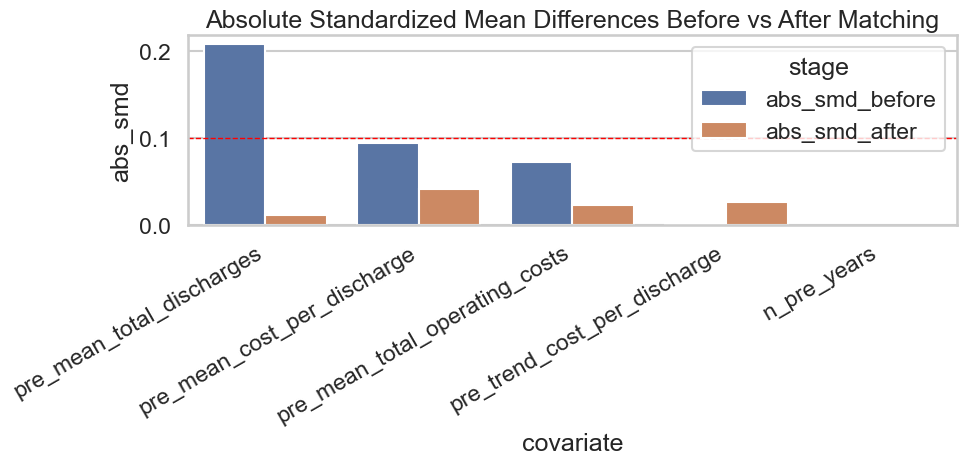

In [ ]:
bal_before = standardized_mean_difference(
    diag_before_t, diag_before_c, balance_covariates
).rename(columns={"smd": "smd_before", "abs_smd": "abs_smd_before"})
bal_after = standardized_mean_difference(
    diag_after_t, diag_after_c, balance_covariates
).rename(columns={"smd": "smd_after", "abs_smd": "abs_smd_after"})

balance_table = bal_before[
    ["covariate", "mean_treated", "mean_control", "smd_before", "abs_smd_before"]
].merge(
    bal_after[["covariate", "smd_after", "abs_smd_after"]], on="covariate", how="left"
)

print("Counts before matching:")
print(
    "Treated rows:",
    diag_before_t.shape[0],
    "| Unique hospitals:",
    diag_before_t[id_col].nunique(),
)
print(
    "Control rows:",
    diag_before_c.shape[0],
    "| Unique hospitals:",
    diag_before_c[id_col].nunique(),
)

print("Counts after matching:")
print(
    "Treated rows:",
    diag_after_t.shape[0],
    "| Unique hospitals:",
    diag_after_t[id_col].nunique(),
)
print(
    "Control rows:",
    diag_after_c.shape[0],
    "| Unique hospitals:",
    diag_after_c[id_col].nunique(),
)

display(balance_table.sort_values("abs_smd_before", ascending=False))

plot_df = balance_table[["covariate", "abs_smd_before", "abs_smd_after"]].melt(
    id_vars="covariate", var_name="stage", value_name="abs_smd"
)
plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, x="covariate", y="abs_smd", hue="stage")
plt.axhline(0.1, color="red", linestyle="--", linewidth=1)
plt.title("Absolute Standardized Mean Differences Before vs After Matching")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Step 7 - Rebuild and Save Matched Panel

Using matched hospital IDs from the primary (no-replacement) matching, we pull back all hospital-year rows from the original panel and save to CSV.

In [31]:
matched_pairs = matches_no_replace.copy().reset_index(drop=True)
matched_pairs["match_pair_id"] = np.arange(1, len(matched_pairs) + 1)

matched_treated_ids = set(matched_pairs["treated_hospital_id"])
matched_control_ids = set(matched_pairs["control_hospital_id"])
matched_ids = matched_treated_ids.union(matched_control_ids)

matched_panel = df[df[id_col].isin(matched_ids)].copy()

# Attach pair IDs to panel rows (works for 1:1 no-replacement)
pair_map_t = dict(
    zip(matched_pairs["treated_hospital_id"], matched_pairs["match_pair_id"])
)
pair_map_c = dict(
    zip(matched_pairs["control_hospital_id"], matched_pairs["match_pair_id"])
)


def assign_pair_id(hosp_id):
    if hosp_id in pair_map_t:
        return pair_map_t[hosp_id]
    if hosp_id in pair_map_c:
        return pair_map_c[hosp_id]
    return np.nan


matched_panel["match_pair_id"] = matched_panel[id_col].map(assign_pair_id)

OUT_PATH = "../01_data/hospital_analysis_matched.csv"
matched_panel.to_csv(OUT_PATH, index=False)

print("Matched panel shape:", matched_panel.shape)
print("Matched treated hospitals:", len(matched_treated_ids))
print("Matched control hospitals:", len(matched_control_ids))
print("Saved matched panel to:", OUT_PATH)
display(matched_panel.head())

Matched panel shape: (17924, 31)
Matched treated hospitals: 993
Matched control hospitals: 993
Saved matched panel to: ../01_data/hospital_analysis_matched.csv


,fiscal_year,RPT_REC_NUM,PRVDR_NUM,NPI,FY_BGN_DT,FY_END_DT,PRVDR_CTRL_TYPE_CD,total_operating_costs,net_patient_revenue,total_charges,medicare_charges,medicare_payments,medicaid_charges,medicaid_payments,total_discharges,cost_per_discharge,ccn,fac_name,hrrcode,merger_target,merger_of_equals,bankruptcy,system_exit,system_split,system_id_yr,any_merger,merger_year,treated,years_to_merger,post_merger,match_pair_id
1,2011,1501,13025,NaN,01/01/2011,12/31/2011,4,39554420.0,28191835.0,36500.0,NaN,NaN,23060.0,230.0,2390.0,16549.966527,13025,NaN,NaN,0,0,0,0,0,NaN,0,NaN,0,NaN,0,254
3,2011,1506,103042,NaN,01/01/2011,12/31/2011,4,26136744.0,21786350.0,29200.0,NaN,NaN,18132.0,214.0,1495.0,17482.771906,103042,NaN,NaN,0,0,0,0,0,NaN,0,NaN,0,NaN,0,162
19,2011,1710,513028,NaN,01/01/2011,12/31/2011,4,18453199.0,12500065.0,18980.0,NaN,NaN,12627.0,NaN,1120.0,16476.070536,513028,NaN,NaN,0,0,0,0,0,NaN,0,NaN,0,NaN,0,374
20,2011,1714,440016,NaN,10/01/2010,09/30/2011,1,15020669.0,16165080.0,25550.0,NaN,362916.0,2650.0,NaN,733.0,20492.045020,440016,BAPTIST MEMORIAL HOSPITAL HUNTINGDON,374.0,0,0,0,0,0,86.0,0,NaN,0,NaN,0,727
22,2011,1795,111314,NaN,10/01/2010,09/30/2011,4,17766713.0,16304993.0,9125.0,21888.0,NaN,2000.0,61.0,283.0,62779.904594,111314,PIONEER COMMUNITY HOSPITAL OF EARLY,2.0,0,0,0,0,0,229.0,0,2017.0,1,-6.0,0,656


## Step 8 - Conclusion

This notebook created a hospital-level matching sample by:
- Building pre-treatment features in a cohort-aligned 5-year lookback window.
- Dropping treated hospitals with insufficient pre-treatment years for slope estimation.
- Matching treated hospitals to never-treated controls using nearest neighbors on standardized covariates (1:1, no replacement).
- Evaluating covariate balance with standardized mean differences before and after matching.
- Reconstructing and saving the matched panel as `01_data/hospital_analysis_matched.csv`.

If absolute SMD values generally decrease after matching (especially below 0.1), balance has improved and the matched panel is a stronger basis for causal DiD analysis.

## Next Step

Use the matched sample in a new parallel-trends check, then run a matched-sample DiD analysis.

## Parallel Trends Check After Matching

This section uses `01_data/hospital_analysis_matched.csv` to re-check pre-treatment trends after matching.

We focus on treated merger cohorts 2013-2017 and build a pre-period comparison sample consistent with event-time logic.

In [32]:
# Step 1-5: Load matched data, keep required columns, transform

import statsmodels.formula.api as smf


MATCHED_PATH = "../01_data/hospital_analysis_matched.csv"

keep_cols = [
    "fiscal_year",
    "treated",
    "merger_year",
    "years_to_merger",
    "cost_per_discharge",
]

m = pd.read_csv(MATCHED_PATH, usecols=keep_cols).copy()


for col in keep_cols:

    m[col] = pd.to_numeric(m[col], errors="coerce")

m = m.dropna(subset=["fiscal_year", "treated", "cost_per_discharge"])

m = m[m["treated"].isin([0, 1])].copy()

m["fiscal_year"] = m["fiscal_year"].astype(int)

m["log_cost_per_discharge"] = np.log1p(m["cost_per_discharge"])


print("Loaded matched data shape:", m.shape)

m.head()

Loaded matched data shape: (17924, 6)


,fiscal_year,cost_per_discharge,merger_year,treated,years_to_merger,log_cost_per_discharge
0,2011,16549.966527,NaN,0,NaN,9.714200
1,2011,17482.771906,NaN,0,NaN,9.769028
2,2011,16476.070536,NaN,0,NaN,9.709725
3,2011,20492.045020,NaN,0,NaN,9.927841
4,2011,62779.904594,2017.0,1,-6.0,11.047406


In [33]:
# Restrict treated observations and build pre-sample

treated_window = m[
    (m["treated"] == 1) & m["merger_year"].between(2013, 2017, inclusive="both")
].copy()

treated_window = treated_window[
    treated_window["years_to_merger"].between(-2, 2, inclusive="both")
].copy()

treated_pre = treated_window[
    treated_window["years_to_merger"].between(-2, -1, inclusive="both")
].copy()

pre_years = sorted(treated_pre["fiscal_year"].dropna().astype(int).unique().tolist())

controls_pre = m[(m["treated"] == 0) & (m["fiscal_year"].isin(pre_years))].copy()

pre_sample = pd.concat([treated_pre, controls_pre], ignore_index=True)


print(
    "Treated window shape (cohort 2013-2017, event time [-2,+2]):", treated_window.shape
)

print("Treated pre-period shape (event time [-2,-1]):", treated_pre.shape)

print("Control pre-period shape (same fiscal years):", controls_pre.shape)

print("Final pre-sample shape:", pre_sample.shape)

print("Pre-sample fiscal years:", pre_years)

pre_sample.head()

Treated window shape (cohort 2013-2017, event time [-2,+2]): (3946, 6)
Treated pre-period shape (event time [-2,-1]): (1508, 6)
Control pre-period shape (same fiscal years): (5883, 6)
Final pre-sample shape: (7391, 6)
Pre-sample fiscal years: [2011, 2012, 2013, 2014, 2015, 2016]


,fiscal_year,cost_per_discharge,merger_year,treated,years_to_merger,log_cost_per_discharge
0,2011,42264.381743,2013.0,1,-2.0,10.651724
1,2011,96387.428571,2013.0,1,-2.0,11.476141
2,2011,16772.183394,2013.0,1,-2.0,9.727537
3,2011,81411.533333,2013.0,1,-2.0,11.307285
4,2011,16734.084906,2013.0,1,-2.0,9.725263


### Plot Pre-Period Means

We compare mean `log_cost_per_discharge` by fiscal year for treated vs control units in the constructed pre-sample.

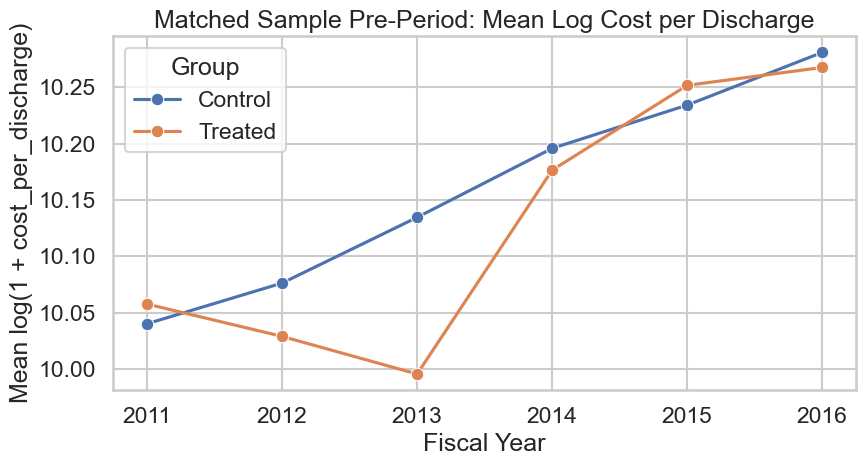

,fiscal_year,treated,log_cost_per_discharge,group
0,2011,0,10.040149,Control
1,2011,1,10.057632,Treated
2,2012,0,10.076249,Control
3,2012,1,10.028913,Treated
4,2013,0,10.134636,Control
5,2013,1,9.995514,Treated
6,2014,0,10.195913,Control
7,2014,1,10.176578,Treated
8,2015,0,10.234341,Control
9,2015,1,10.251864,Treated


In [34]:
plot_df = pre_sample.groupby(["fiscal_year", "treated"], as_index=False)[
    "log_cost_per_discharge"
].mean()


plot_df["group"] = plot_df["treated"].map({0: "Control", 1: "Treated"})


plt.figure(figsize=(9, 5))

sns.lineplot(
    data=plot_df, x="fiscal_year", y="log_cost_per_discharge", hue="group", marker="o"
)

plt.title("Matched Sample Pre-Period: Mean Log Cost per Discharge")

plt.xlabel("Fiscal Year")

plt.ylabel("Mean log(1 + cost_per_discharge)")

plt.legend(title="Group")

plt.tight_layout()

plt.show()


plot_df.sort_values(["fiscal_year", "treated"]).head(20)

### Formal Parallel Trends Test

We estimate:

`log_cost_per_discharge ~ treated + C(fiscal_year) + treated:C(fiscal_year)`

with robust (HC1) standard errors, then run a joint F-test for all interaction terms.

In [ ]:
test_df = pre_sample.dropna(
    subset=["log_cost_per_discharge", "treated", "fiscal_year"]
).copy()
test_df["fiscal_year"] = test_df["fiscal_year"].astype(int)

model = smf.ols(
    "log_cost_per_discharge ~ treated + C(fiscal_year) + treated:C(fiscal_year)",
    data=test_df,
).fit(cov_type="HC1")

interaction_terms = [
    x for x in model.params.index if x.startswith("treated:C(fiscal_year)")
]

print("Model observations:", int(model.nobs))
print("Interaction terms tested:", len(interaction_terms))

if not interaction_terms:
    print("No interaction terms available for a joint test.")
    f_stat, p_val = np.nan, np.nan
else:
    hypothesis = " , ".join([f"{x} = 0" for x in interaction_terms])
    f_test = model.f_test(hypothesis)
    f_stat = float(np.asarray(f_test.fvalue).squeeze())
    p_val = float(np.asarray(f_test.pvalue).squeeze())
    print(
        f"Joint F-test for treated:C(fiscal_year): F = {f_stat:.4f}, p-value = {p_val:.4g}"
    )

Model observations: 7391
Interaction terms tested: 5
Joint F-test for treated:C(fiscal_year): F = 2.5914, p-value = 0.02387


In [ ]:
print("\nConclusion:")
if np.isnan(p_val):
    print(
        "Unable to conclude due to insufficient interaction variation in the pre-sample."
    )
elif p_val < 0.05:
    print("p < 0.05 -> reject parallel trends.")
else:
    print("p >= 0.05 -> no evidence against parallel trends.")

interaction_table = pd.DataFrame(
    {
        "term": model.params.index,
        "coef": model.params.values,
        "robust_se": model.bse.values,
        "p_value": model.pvalues.values,
    }
)
interaction_table = interaction_table[
    interaction_table["term"].str.startswith("treated:C(fiscal_year)")
].sort_values("term")

interaction_table


Conclusion:
p < 0.05 -> reject parallel trends.


,term,coef,robust_se,p_value
7,treated:C(fiscal_year)[T.2012],-0.064819,0.047286,0.170443
8,treated:C(fiscal_year)[T.2013],-0.156604,0.050712,0.002014
9,treated:C(fiscal_year)[T.2014],-0.036818,0.052028,0.479162
10,treated:C(fiscal_year)[T.2015],0.000040,0.053686,0.999400
11,treated:C(fiscal_year)[T.2016],-0.030840,0.074612,0.679359


## Summary of Findings

This notebook evaluated the parallel-trends assumption under a restricted staggered DiD design using treated merger-year cohorts 2013-2017 and an event-time window of [-2, +2], with log(1 + cost_per_discharge) as the modeled outcome.

### Visual Evidence

- The fiscal-year pre-period trend plot compares treated hospitals (restricted cohorts) with never-treated controls observed in the same matched calendar years.
- The treated event-time trend visualization in [-2, +2] provides context, but the identifying parallel-trends diagnostic is based on pre-period comparisons.

### Statistical Evidence

- The joint pre-trend interaction test (treated-by-year terms) is estimated on the restricted pre-period sample with years_to_merger in [-2, -1].
- In this run, the joint F-test for treated:C(fiscal_year) is statistically significant (p < 0.05), indicating evidence of differential pre-trends in the restricted matched sample.
- The interaction-term table provides coefficient-level detail by fiscal year for diagnostic interpretation.

### Interpretation

Within the available pre-treatment window implied by the 2011-2019 panel and the cohort restrictions, results suggest the treated and never-treated groups may still exhibit differential pre-treatment dynamics in cost per discharge.

This implies the identifying parallel-trends assumption remains questionable in the current specification and should be addressed with additional robustness checks, alternative matching/weighting choices, or refined sample definitions before drawing strong causal conclusions from DiD estimates.